In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display
import ipywidgets as widgets
from ipywidgets import interact, Dropdown, Button, HBox, VBox, IntSlider, Play, jslink
import seaborn as sns
from collections import Counter, defaultdict
import ast
from itertools import combinations
import re
import warnings
warnings.filterwarnings('ignore')

from google.colab import output, files
output.enable_custom_widget_manager()

# Set matplotlib to display inline
%matplotlib inline

# Set up plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Load the dataset
df = pd.read_csv('CardsDataset.csv')

# Display basic info
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (845, 168)


,participant,Trials per task,Task,condition,Trials2correct,trialN,trial_ends,movement_codes,final_card_positions_1,final_card_position_codes_1,...,move_47_upTime,move_48,move_48_downTime,move_48_upTime,move_49,move_49_downTime,move_49_upTime,move_50,move_50_downTime,move_50_upTime
0,57,1.0,1,KQJB,1,0,submit,"['queen_spades_cA1', 'king_diamonds_cA2', 'jac...","[""queen_spades_c"",""king_diamonds_c"",""jack_diam...","['queen_spades_cA1', 'king_diamonds_cA2', 'jac...",...,,,,,,,,,,
1,58,NaN,1,KQ,0,0,submit,"['queen_spades_aA2', 'queen_clubs_aB2', 'queen...","[null,""queen_spades_a"",""king_diamonds_a"",null,...","['queen_spades_aA2', 'king_diamonds_aA3', 'que...",...,,,,,,,,,,
2,58,NaN,1,KQ,0,1,reset,[],"[null,null,null,null,null,null,null,null,null,...",[],...,,,,,,,,,,
3,58,NaN,1,KQ,0,2,submit,"['queen_spades_aA2', 'queen_clubs_aA4', 'queen...","[null,""queen_spades_a"",null,""king_diamonds_a"",...","['queen_spades_aA2', 'king_diamonds_aA4', 'que...",...,,,,,,,,,,
4,58,4.0,1,KQ,4,3,submit,"['queen_spades_aA2', 'king_diamonds_aC2', 'que...","[null,null,""queen_spades_a"",null,""king_clubs_a...","['queen_spades_aA3', 'king_clubs_aA5', 'king_d...",...,,,,,,,,,,


In [ ]:
# Basic statistics
print(f"\nTotal participants: {df['participant'].nunique()}")
print(f"Conditions: {df['condition'].unique()}")
print(f"Success rate: {df['overall_correct'].mean():.2%}")


Total participants: 228
Conditions: ['KQJB' 'KQ' 'KQB' 'KQJ']
Success rate: 12.66%


In [ ]:
# Data preprocessing functions
def safe_literal_eval(x):
    # Safely evaluate string representations of lists
    if pd.isna(x) or x == '' or x == '[]':
        return []
    try:
        return ast.literal_eval(x) if isinstance(x, str) else x
    except:
        return []

def clean_card_positions(movement_list):
    if not isinstance(movement_list, list):
        return movement_list  # safety fallback

    cleaned_list = []

    for move in movement_list:
        if not isinstance(move, str):
            cleaned_list.append(move)
            continue

        parts = move.split('_')

        # Case 1: last part starts with a lowercase letter → remove it
        if re.match(r'^[a-z]', parts[-1]):
            parts[-1] = parts[-1][1:]

        # Case 2: second last part is just 'c' → remove it
        elif len(parts) >= 2 and parts[-2] == 'c':
            parts.pop(-2)

        cleaned_list.append("_".join(parts))

    return cleaned_list


def extract_card_info(move_str):
    # Extract card type and position from movement string
    if pd.isna(move_str) or move_str == '':
        return None, None
    try:
        parts = move_str.split('_')
        if len(parts) >= 3:
            card_type = f"{parts[0]}_{parts[1]}"  # e.g., queen_spades
            position = parts[-1]  # e.g., cA1
            return card_type, position
    except:
        pass
    return None, None

def extract_card_type_only(move_str):
    # Extract only card type from movement string
    card_type, _ = extract_card_info(move_str)
    return card_type

def analyze_movement_patterns(movements):
    # Analyze patterns in movement sequences
    if not movements:
        return {}

    patterns = {
        'total_moves': len(movements),
        'unique_cards_moved': len(set(movements)),
        'repeated_moves': len(movements) - len(set(movements)),
        'off_grid_moves': sum('Off Grid' in str(move) for move in movements),
        'move_types': Counter([move.split('_')[0] if '_' in str(move) else 'unknown' for move in movements])
    }
    return patterns

def extract_sequence_features(sequence):
    # Extract features from movement sequence
    if not sequence:
        return {}

    features = {
        'has_off_grid': any('Off Grid' in str(move) for move in sequence),
        'has_repeats': len(sequence) != len(set(sequence)),
        'card_types': [],
        'positions': []
    }

    for move in sequence:
        card_type, position = extract_card_info(move)
        if card_type:
            features['card_types'].append(card_type)
        if position:
            features['positions'].append(position)

    features['unique_card_types'] = len(set(features['card_types']))
    features['unique_positions'] = len(set(features['positions']))

    return features

In [ ]:
# Apply preprocessing
df['movement_codes'] = df['movement_codes'].apply(safe_literal_eval)
df['movement_codes'] = df['movement_codes'].apply(clean_card_positions)

df['final_card_position_codes_1'] = df['final_card_position_codes_1'].apply(safe_literal_eval)
df['final_card_position_codes_1'] = df['final_card_position_codes_1'].apply(clean_card_positions)


# Add derived columns
df['movement_patterns'] = df['movement_codes'].apply(analyze_movement_patterns)
df['sequence_features'] = df['movement_codes'].apply(extract_sequence_features)
df['is_success'] = df['overall_correct'] == 1

# Extract pattern metrics
def safe_get(pattern_dict, key, default=0):
    # Safely get value from pattern dictionary
    if pattern_dict and isinstance(pattern_dict, dict):
        return pattern_dict.get(key, default)
    return default

df['total_moves'] = df['movement_patterns'].apply(lambda x: safe_get(x, 'total_moves'))
df['off_grid_count'] = df['movement_patterns'].apply(lambda x: safe_get(x, 'off_grid_moves'))
df['repeated_moves'] = df['movement_patterns'].apply(lambda x: safe_get(x, 'repeated_moves'))

df['off_grid_ratio'] = df.apply(
    lambda row: row['off_grid_count'] / row['total_moves'] if row['total_moves'] > 0 else 0,
    axis=1
)
df['repeat_ratio'] = df.apply(
    lambda row: row['repeated_moves'] / row['total_moves'] if row['total_moves'] > 0 else 0,
    axis=1
)


# Create success and failure dataframes
success_df = df[df['is_success'] == True]
failure_df = df[df['is_success'] == False]

print(f"Successful trials: {len(success_df)}")
print(f"Failed trials: {len(failure_df)}")
df

Successful trials: 107
Failed trials: 738


,participant,Trials per task,Task,condition,Trials2correct,trialN,trial_ends,movement_codes,final_card_positions_1,final_card_position_codes_1,...,move_50_downTime,move_50_upTime,movement_patterns,sequence_features,is_success,total_moves,off_grid_count,repeated_moves,off_grid_ratio,repeat_ratio
0,57,1.0,1,KQJB,1,0,submit,"[queen_spades_A1, king_diamonds_A2, jack_diamo...","[""queen_spades_c"",""king_diamonds_c"",""jack_diam...","[queen_spades_A1, king_diamonds_A2, jack_diamo...",...,,,"{'total_moves': 37, 'unique_cards_moved': 17, ...","{'has_off_grid': True, 'has_repeats': True, 'c...",True,37,4,20,0.108108,0.540541
1,58,NaN,1,KQ,0,0,submit,"[queen_spades_A2, queen_clubs_B2, queen_diamon...","[null,""queen_spades_a"",""king_diamonds_a"",null,...","[queen_spades_A2, king_diamonds_A3, queen_club...",...,,,"{'total_moves': 12, 'unique_cards_moved': 12, ...","{'has_off_grid': True, 'has_repeats': False, '...",False,12,1,0,0.083333,0.000000
2,58,NaN,1,KQ,0,1,reset,[],"[null,null,null,null,null,null,null,null,null,...",[],...,,,{},{},False,0,0,0,0.000000,0.000000
3,58,NaN,1,KQ,0,2,submit,"[queen_spades_A2, queen_clubs_A4, queen_diamon...","[null,""queen_spades_a"",null,""king_diamonds_a"",...","[queen_spades_A2, king_diamonds_A4, queen_club...",...,,,"{'total_moves': 21, 'unique_cards_moved': 16, ...","{'has_off_grid': True, 'has_repeats': True, 'c...",False,21,1,5,0.047619,0.238095
4,58,4.0,1,KQ,4,3,submit,"[queen_spades_A2, king_diamonds_C2, queen_club...","[null,null,""queen_spades_a"",null,""king_clubs_a...","[queen_spades_A3, king_clubs_A5, king_diamonds...",...,,,"{'total_moves': 16, 'unique_cards_moved': 15, ...","{'has_off_grid': False, 'has_repeats': True, '...",True,16,0,1,0.000000,0.062500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
840,327,1.0,1,KQJB,1,0,submit,"[queen_hearts_A1, king_spades_Off Grid, king_s...","[""queen_hearts_c"",""king_spades_c"",""jack_spades...","[queen_hearts_A1, king_spades_A2, jack_spades_...",...,,,"{'total_moves': 24, 'unique_cards_moved': 17, ...","{'has_off_grid': True, 'has_repeats': True, 'c...",True,24,3,7,0.125000,0.291667
841,329,NaN,1,KQB,0,0,submit,"[queen_spades_B1, queen_clubs_B3, queen_diamon...","[null,null,null,null,null,null,null,null,null,...","[queen_diamonds_B6, blank3_B8, queen_spades_C1...",...,,,"{'total_moves': 28, 'unique_cards_moved': 12, ...","{'has_off_grid': True, 'has_repeats': True, 'c...",False,28,5,16,0.178571,0.571429
842,329,2.0,1,KQB,2,1,submit,"[queen_clubs_Off Grid, queen_clubs_B1, queen_s...","[null,null,null,null,null,null,null,null,null,...",[],...,,,"{'total_moves': 13, 'unique_cards_moved': 8, '...","{'has_off_grid': True, 'has_repeats': True, 'c...",True,13,4,5,0.307692,0.384615
843,330,1.0,1,KQJ,1,0,submit,"[queen_spades_A1, king_diamonds_B2, king_diamo...","[""queen_spades_d"",""jack_spades_d"",""king_spades...","[queen_spades_A1, jack_spades_A2, king_spades_...",...,,,"{'total_moves': 31, 'unique_cards_moved': 26, ...","{'has_off_grid': False, 'has_repeats': True, '...",True,31,0,5,0.000000,0.161290


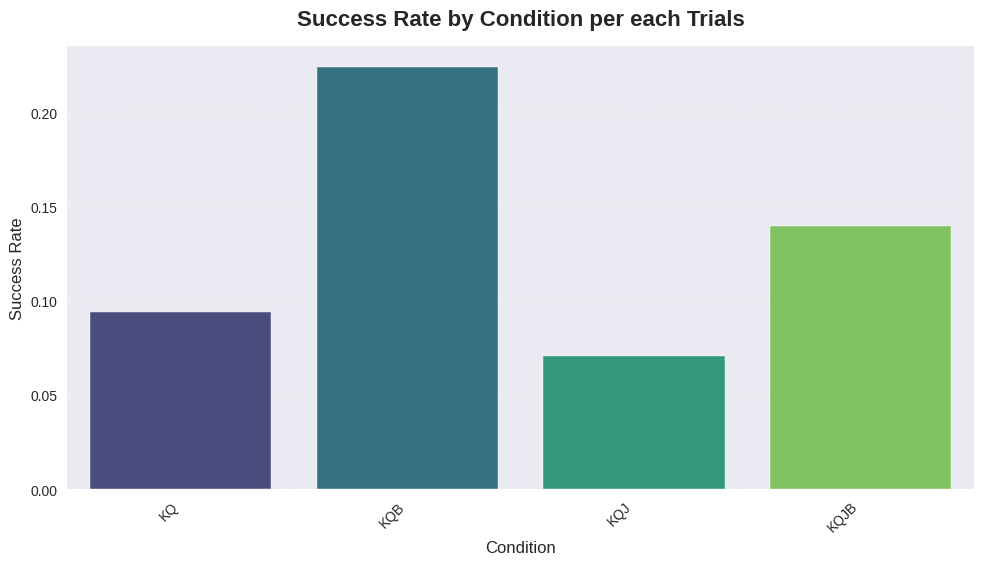

In [ ]:
# Visualization: Success by Condition
def success_by_condition(condition_df):
    success_by_condition = condition_df.groupby('condition')['is_success'].mean().reset_index()

    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=success_by_condition,
        x='condition',
        y='is_success',
        palette='viridis'
    )

    # Titles and labels (consistent style)
    plt.title('Success Rate by Condition per each Trials', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('Condition', fontsize=12)
    plt.ylabel('Success Rate', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

success_by_condition(df)

Metrics Comparison:
           Metric    Success    Failure
0     Total Moves  16.859813  13.037940
1  Off-Grid Moves   2.392523   2.325203
2  Repeated Moves   5.504673   3.804878


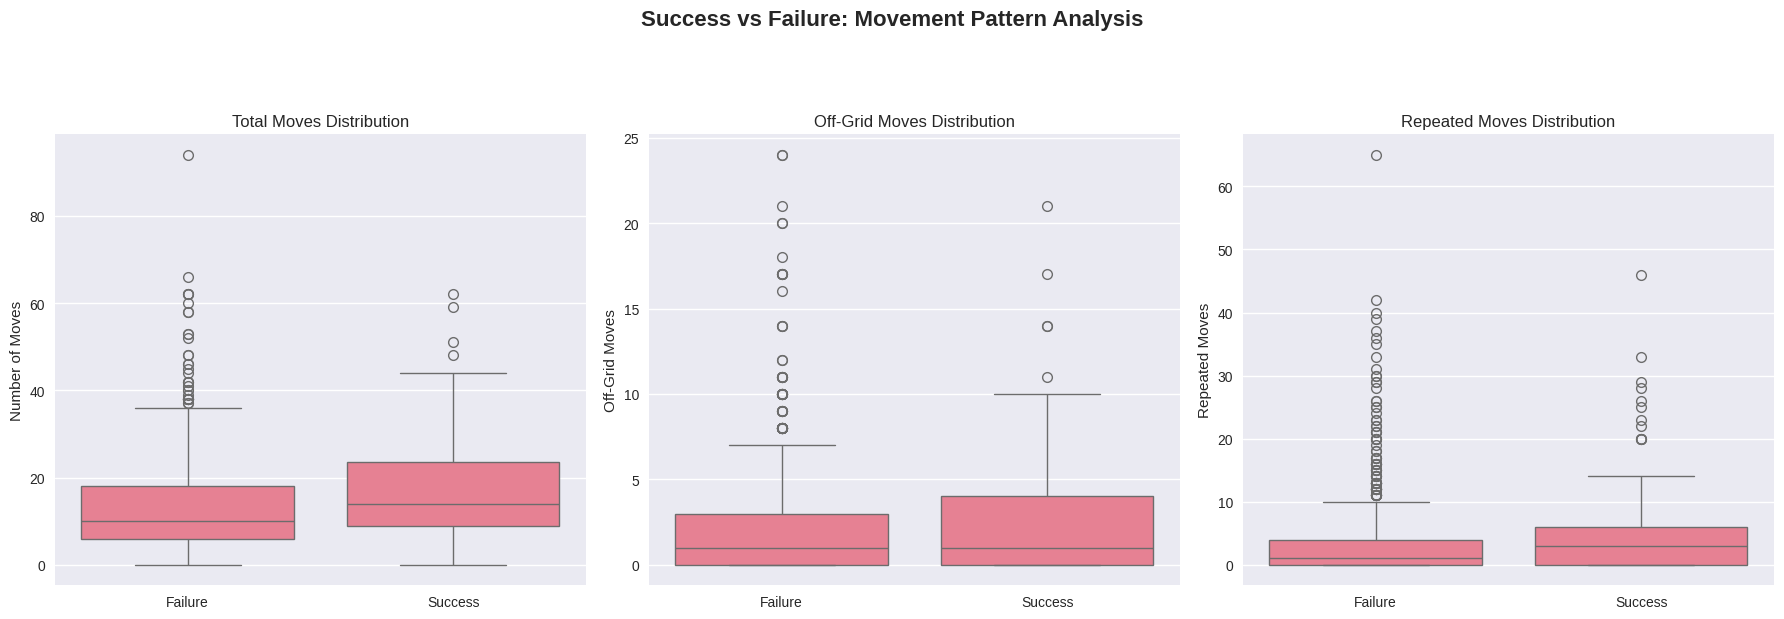

In [ ]:
# Compare metrics
metrics_comparison = pd.DataFrame({
    'Metric': ['Total Moves', 'Off-Grid Moves', 'Repeated Moves'],
    'Success': [
        success_df['total_moves'].mean(),
        success_df['off_grid_count'].mean(),
        success_df['repeated_moves'].mean()
    ],
    'Failure': [
        failure_df['total_moves'].mean(),
        failure_df['off_grid_count'].mean(),
        failure_df['repeated_moves'].mean()
    ]
})

print("Metrics Comparison:")
print(metrics_comparison)

# Visualization: Comparison of key metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Success vs Failure: Movement Pattern Analysis', fontsize=16, fontweight='bold', y=1.03)

# Plot 1: Total moves
sns.boxplot(data=df, x='is_success', y='total_moves', ax=axes[0])
axes[0].set_title('Total Moves Distribution')
axes[0].set_xlabel('')
axes[0].set_ylabel('Number of Moves')
axes[0].set_xticklabels(['Failure', 'Success'])

# Plot 2: Off-grid moves
sns.boxplot(data=df, x='is_success', y='off_grid_count', ax=axes[1])
axes[1].set_title('Off-Grid Moves Distribution')
axes[1].set_xlabel('')
axes[1].set_ylabel('Off-Grid Moves')
axes[1].set_xticklabels(['Failure', 'Success'])

# Plot 3: Repeated moves
sns.boxplot(data=df, x='is_success', y='repeated_moves', ax=axes[2])
axes[2].set_title('Repeated Moves Distribution')
axes[2].set_xlabel('')
axes[2].set_ylabel('Repeated Moves')
axes[2].set_xticklabels(['Failure', 'Success'])

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
# Analysis: Movement Sequence Patterns (FIRST 3 MOVES)
def analyze_common_sequences(trials, top_n=10):
    sequence_counter = Counter()

    for sequence in trials:
        if sequence and len(sequence) > 0:
            # Convert to tuple for hashing, use FIRST 3 MOVES for pattern analysis
            seq_tuple = tuple(sequence[:3])  # FIRST 3 MOVES
            sequence_counter[seq_tuple] += 1
    return sequence_counter.most_common(top_n)

# Get common sequences for success and failure (FIRST 3 MOVES)
success_sequences = analyze_common_sequences(success_df['movement_codes'])
failure_sequences = analyze_common_sequences(failure_df['movement_codes'])

print("Top 5 Successful Sequences (FIRST 3 MOVES):")
for i, (seq, count) in enumerate(success_sequences[:5], 1):
    print(f"{i}. {seq} (count: {count})")

print("Top 5 Failure Sequences (FIRST 3 MOVES):")
for i, (seq, count) in enumerate(failure_sequences[:5], 1):
    print(f"{i}. {seq} (count: {count})")

Top 5 Successful Sequences (FIRST 3 MOVES):
1. ('queen_spades_A1', 'king_diamonds_A2', 'jack_diamonds_A3') (count: 4)
2. ('queen_spades_A1', 'queen_clubs_B2', 'queen_diamonds_C3') (count: 2)
3. ('queen_diamonds_B2', 'queen_clubs_C3', 'queen_spades_D4') (count: 2)
4. ('queen_spades_A1', 'queen_spades_A1', 'king_diamonds_C1') (count: 2)
5. ('queen_clubs_Off Grid', 'queen_clubs_Off Grid', 'queen_clubs_A1') (count: 2)
Top 5 Failure Sequences (FIRST 3 MOVES):
1. ('queen_spades_A1', 'queen_clubs_B2', 'queen_diamonds_C3') (count: 14)
2. ('queen_spades_A1', 'queen_spades_A1', 'queen_spades_A1') (count: 14)
3. ('queen_spades_A1', 'king_diamonds_A2', 'jack_diamonds_A3') (count: 7)
4. ('queen_spades_Off Grid', 'queen_spades_Off Grid', 'queen_spades_A1') (count: 5)
5. ('queen_spades_A1', 'king_diamonds_B1', 'jack_diamonds_C1') (count: 5)



Most Common FIRST MOVES (Successful Trials):
  queen_spades_A1: 26 times
  queen_diamonds_A1: 7 times
  queen_spades_Off Grid: 5 times
  queen_clubs_Off Grid: 4 times
  queen_spades_A2: 3 times
  queen_diamonds_B2: 3 times
  queen_spades_D1: 3 times
  queen_hearts_B1: 3 times

Most Common FIRST MOVES (Failed Trials):
  queen_spades_A1: 132 times
  queen_spades_Off Grid: 46 times
  queen_spades_B1: 43 times
  queen_diamonds_A1: 27 times
  queen_hearts_A1: 27 times
  king_clubs_Off Grid: 21 times
  queen_clubs_A1: 17 times
  king_hearts_Off Grid: 16 times


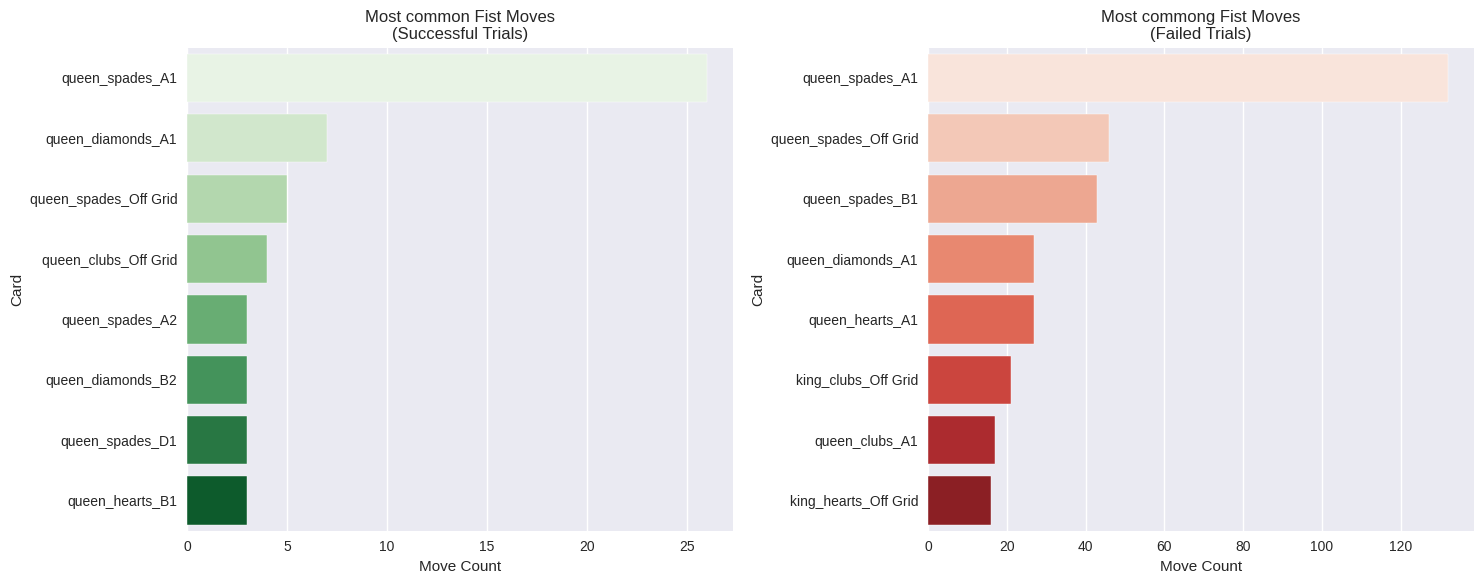

In [ ]:
def analyze_opening_moves(sequences):
    # Analyze the very first move in sequences
    first_move_counter = Counter()

    for sequence in sequences:
        if sequence and len(sequence) > 0:
            first_move = sequence[0]
            if first_move and first_move != '':
                first_move_counter[first_move] += 1

    return first_move_counter

success_first_moves = analyze_opening_moves(success_df['movement_codes'])
failure_first_moves = analyze_opening_moves(failure_df['movement_codes'])

print("\nMost Common FIRST MOVES (Successful Trials):")
for card, count in success_first_moves.most_common(8):
    print(f"  {card}: {count} times")

print("\nMost Common FIRST MOVES (Failed Trials):")
for card, count in failure_first_moves.most_common(8):
    print(f"  {card}: {count} times")

# Visualization: Card usage comparison in first move
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Success card usage (first move)
if success_first_moves:
    success_cards_df = pd.DataFrame(success_first_moves.most_common(8), columns=['Card', 'Count'])
    sns.barplot(data=success_cards_df, x='Count', y='Card', ax=ax1, palette='Greens')
    ax1.set_title('Most common Fist Moves\n(Successful Trials)')
    ax1.set_xlabel('Move Count')

# Failure card usage (first move)
if failure_first_moves:
    failure_cards_df = pd.DataFrame(failure_first_moves.most_common(8), columns=['Card', 'Count'])
    sns.barplot(data=failure_cards_df, x='Count', y='Card', ax=ax2, palette='Reds')
    ax2.set_title('Most commong Fist Moves\n(Failed Trials)')
    ax2.set_xlabel('Move Count')

plt.tight_layout()
plt.show()

Top 5 common TRANSITIONS (Successful Trials):
1. queen_spades_A1 → king_diamonds_A2 → jack_diamonds_A3 → queen_clubs_C2 → queen_diamonds_B3 (count: 3)
2. king_diamonds_A2 → jack_diamonds_A3 → queen_clubs_C2 → queen_diamonds_B3 → queen_hearts_D4 (count: 3)
3. jack_diamonds_A3 → queen_clubs_C2 → queen_diamonds_B3 → queen_hearts_D4 → jack_hearts_B2 (count: 3)
4. queen_spades_A2 → king_diamonds_C2 → queen_clubs_A4 → king_hearts_D4 → queen_diamonds_C6 (count: 1)
5. king_diamonds_C2 → queen_clubs_A4 → king_hearts_D4 → queen_diamonds_C6 → king_clubs_B6 (count: 1)

Top 5 common TRANSITIONS (Failed Trials):
1. king_diamonds_B1 → king_hearts_C2 → king_clubs_D3 → king_spades_E4 → jack_diamonds_C1 (count: 4)
2. queen_spades_A1 → queen_clubs_B2 → queen_diamonds_C3 → queen_hearts_D4 → king_diamonds_B1 (count: 3)
3. queen_clubs_B2 → queen_diamonds_C3 → queen_hearts_D4 → king_diamonds_B1 → king_hearts_C2 (count: 3)
4. queen_diamonds_C3 → queen_hearts_D4 → king_diamonds_B1 → king_hearts_C2 → king_clubs

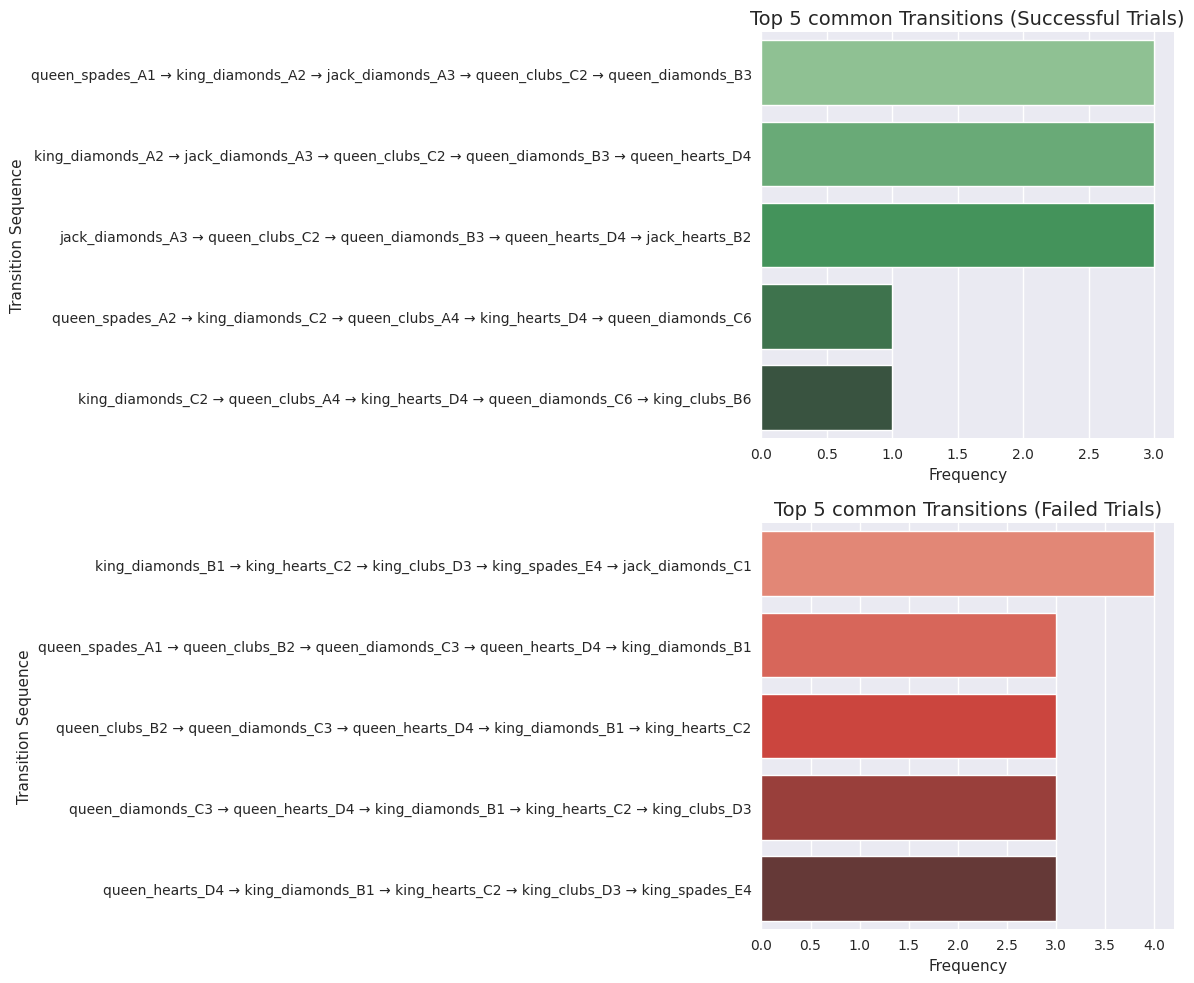

In [ ]:
# Function to analyze transitions between moves
def analyze_transitions(sequences, transition_length=5, max_transitions=10):
    transition_counter = Counter()

    for sequence in sequences:
        if sequence and len(sequence) >= transition_length:
            # Analyze n-card transitions
            for i in range(len(sequence) - transition_length + 1):
                moves = sequence[i:i + transition_length]

                # Skip if any consecutive moves are identical
                if any(moves[j] == moves[j + 1] for j in range(len(moves) - 1)):
                    continue

                transition = " → ".join(moves)
                transition_counter[transition] += 1

    return transition_counter.most_common(max_transitions)


# Analyze transitions for success and failure
success_transitions = analyze_transitions(success_df['movement_codes'], transition_length=5)
failure_transitions = analyze_transitions(failure_df['movement_codes'], transition_length=5)

print("Top 5 common TRANSITIONS (Successful Trials):")
for i, (transition, count) in enumerate(success_transitions[:5], 1):
    print(f"{i}. {transition} (count: {count})")

print("\nTop 5 common TRANSITIONS (Failed Trials):")
for i, (transition, count) in enumerate(failure_transitions[:5], 1):
    print(f"{i}. {transition} (count: {count})")


# Visualization: Transition Patterns
fig, axes = plt.subplots(2, 1, figsize=(12, 10))
sns.set(style="whitegrid")

# Successful trials
if success_transitions:
    df_success = pd.DataFrame(success_transitions[:5], columns=['Transition', 'Count'])
    sns.barplot(data=df_success, x='Count', y='Transition', ax=axes[0], palette='Greens_d')
    axes[0].set_title('Top 5 common Transitions (Successful Trials)', fontsize=14)
    axes[0].set_xlabel('Frequency')
    axes[0].set_ylabel('Transition Sequence')

# Failed trials
if failure_transitions:
    df_failure = pd.DataFrame(failure_transitions[:5], columns=['Transition', 'Count'])
    sns.barplot(data=df_failure, x='Count', y='Transition', ax=axes[1], palette='Reds_d')
    axes[1].set_title('Top 5 common Transitions (Failed Trials)', fontsize=14)
    axes[1].set_xlabel('Frequency')
    axes[1].set_ylabel('Transition Sequence')

plt.tight_layout()
plt.show()

In [ ]:
class CardPlacementVisualizer:
    """
    Interactive visualizer for card placement movements on an 8x8 grid.
    Reusable class for analyzing card sorting behavior.
    Optimized for Google Colab with smaller, more readable grid size.
    """

    def __init__(self, df, figure_size=(7, 7)):
        """
        Initialize the visualizer with a cleaned dataframe.

        Parameters:
        -----------
        df : pandas.DataFrame
            Cleaned dataframe with movement_codes column
        figure_size : tuple
            Figure size in inches (width, height). Default: (7, 7)
        """
        self.df = df
        self.current_participant = None
        self.current_trial = None
        self.current_movements = []
        self.grid_size = 8
        self.figure_size = figure_size  # Smaller size for better page fit

        # Define card type colors for visual distinction
        self.card_colors = {
            'queen': '#FF6B6B',    # Red
            'king': '#4ECDC4',     # Teal
            'jack': '#45B7D1',     # Blue
            'blank': '#95E1D3',    # Light green
            'empty': '#F7F7F7'     # Light gray
        }

        # Define suit symbols
        self.suit_symbols = {
            'spades': '♠',
            'hearts': '♥',
            'diamonds': '♦',
            'clubs': '♣'
        }

    def parse_position(self, position_str):
        """
        Parse position string (e.g., 'A1', 'B3', 'Off Grid') to grid coordinates.

        Returns:
        --------
        tuple : (row, col) or None if off-grid
        """
        if pd.isna(position_str) or 'Off Grid' in str(position_str):
            return None

        try:
            # Extract letter and number from position string
            position_str = str(position_str).strip()

            # Handle formats like 'A1', 'B2', etc.
            if len(position_str) >= 2:
                col_letter = position_str[0]
                row_num = position_str[1:]

                # Convert letter to column index (A=0, B=1, etc.)
                col = ord(col_letter.upper()) - ord('A')
                # Convert number to row index (1=0, 2=1, etc.)
                row = int(row_num) - 1

                # Validate coordinates
                if 0 <= row < self.grid_size and 0 <= col < self.grid_size:
                    return (row, col)
        except:
            pass

        return None

    def extract_card_info(self, move_str):
        """
        Extract card type, suit, and position from movement string.

        Returns:
        --------
        dict : Contains card_rank, suit, position, color
        """
        if pd.isna(move_str) or move_str == '':
            return None

        try:
            parts = str(move_str).split('_')

            if len(parts) >= 2:
                card_rank = parts[0]  # queen, king, jack, blank
                suit = parts[1] if len(parts) > 1 else ''
                position = parts[-1] if len(parts) > 2 else 'Off Grid'

                # Get color based on card rank
                color = self.card_colors.get(card_rank.lower(), self.card_colors['empty'])

                return {
                    'rank': card_rank,
                    'suit': suit,
                    'position': position,
                    'color': color,
                    'symbol': self.suit_symbols.get(suit, '')
                }
        except:
            pass

        return None

    def create_grid_state(self, movements, step):
        """
        Create grid state at a specific step in the movement sequence.

        Parameters:
        -----------
        movements : list
            List of movement strings
        step : int
            Current step in the sequence (0 to len(movements))

        Returns:
        --------
        numpy.ndarray : 8x8 grid with card information
        """
        # Initialize empty grid
        grid = np.empty((self.grid_size, self.grid_size), dtype=object)

        # Track card positions (last position wins for duplicates)
        card_positions = {}

        # Apply movements up to current step
        for i in range(min(step, len(movements))):
            card_info = self.extract_card_info(movements[i])

            if card_info:
                position_coords = self.parse_position(card_info['position'])

                # Remove card from previous position if it exists
                card_key = f"{card_info['rank']}_{card_info['suit']}"
                if card_key in card_positions:
                    old_row, old_col = card_positions[card_key]
                    if old_row is not None:
                        grid[old_row, old_col] = None

                # Place card at new position
                if position_coords:
                    row, col = position_coords
                    grid[row, col] = card_info
                    card_positions[card_key] = (row, col)
                else:
                    # Card moved off grid
                    card_positions[card_key] = (None, None)

        return grid

    def plot_grid(self, grid, ax, step, total_steps, trial_info):
        """
        Plot the current grid state with optimized sizing.

        Parameters:
        -----------
        grid : numpy.ndarray
            Current grid state
        ax : matplotlib.axes.Axes
            Axes to plot on
        step : int
            Current step number
        total_steps : int
            Total number of steps
        trial_info : dict
            Information about the trial
        """
        ax.clear()

        # Create color grid for background
        color_grid = np.zeros((self.grid_size, self.grid_size, 3))

        # Set background to light gray
        for i in range(self.grid_size):
            for j in range(self.grid_size):
                color_grid[i, j] = [0.97, 0.97, 0.97]

        # Display grid with gridlines
        ax.imshow(color_grid, aspect='auto')

        # Add gridlines
        for i in range(self.grid_size + 1):
            ax.axhline(i - 0.5, color='gray', linewidth=0.8, alpha=0.3)
            ax.axvline(i - 0.5, color='gray', linewidth=0.8, alpha=0.3)

        # Place cards on grid
        for i in range(self.grid_size):
            for j in range(self.grid_size):
                if grid[i, j] is not None:
                    card_info = grid[i, j]

                    # Draw card background
                    rect = plt.Rectangle((j - 0.45, i - 0.45), 0.9, 0.9,
                                        facecolor=card_info['color'],
                                        edgecolor='black',
                                        linewidth=1.5,
                                        alpha=0.9)
                    ax.add_patch(rect)

                    # Add card text (scaled for smaller grid)
                    rank_text = card_info['rank'][0].upper()  # First letter
                    suit_symbol = card_info['symbol']

                    # Display rank and suit
                    ax.text(j, i - 0.1, rank_text,
                           ha='center', va='center',
                           fontsize=12, fontweight='bold',
                           color='white')

                    if suit_symbol:
                        ax.text(j, i + 0.15, suit_symbol,
                               ha='center', va='center',
                               fontsize=10,
                               color='white')

        # Add row labels (1-8)
        for i in range(self.grid_size):
            ax.text(-0.7, i, str(i + 1),
                   ha='center', va='center',
                   fontsize=9, fontweight='bold')

        # Add column labels (A-H)
        for j in range(self.grid_size):
            ax.text(j, -0.7, chr(65 + j),
                   ha='center', va='center',
                   fontsize=9, fontweight='bold')

        # Set axis properties
        ax.set_xlim(-1, self.grid_size)
        ax.set_ylim(self.grid_size, -1)
        ax.axis('off')

        # Add title with trial information
        participant = trial_info.get('participant', 'N/A')
        trial_n = trial_info.get('trialN', 'N/A')
        condition = trial_info.get('condition', 'N/A')
        success = trial_info.get('overall_correct', 0)

        success_text = '✓ Success' if success == 1 else '✗ Failed'
        title_color = 'green' if success == 1 else 'red'

        title = f'Participant {participant} | Trial {trial_n} | Condition: {condition} | {success_text}\n'
        title += f'Step {step}/{total_steps}'

        ax.set_title(title, fontsize=11, fontweight='bold', pad=15,
                    color=title_color if step == total_steps else 'black')

    def animate_trial(self, participant, trial_n):
        """
        Create an animated visualization of card movements for a specific trial.

        Parameters:
        -----------
        participant : int/str
            Participant ID
        trial_n : int
            Trial number

        Returns:
        --------
        matplotlib.animation.FuncAnimation
        """
        # Get trial data
        trial_data = self.df[(self.df['participant'] == participant) &
                            (self.df['trialN'] == trial_n)]

        if trial_data.empty:
            print(f"No data found for Participant {participant}, Trial {trial_n}")
            return None

        trial_data = trial_data.iloc[0]
        movements = trial_data['movement_codes']

        if not movements:
            print(f"No movements found for this trial")
            return None

        # Store current state
        self.current_participant = participant
        self.current_trial = trial_n
        self.current_movements = movements

        # Create figure with smaller size
        fig, ax = plt.subplots(figsize=self.figure_size)

        # Trial information
        trial_info = {
            'participant': participant,
            'trialN': trial_n,
            'condition': trial_data.get('condition', 'N/A'),
            'overall_correct': trial_data.get('overall_correct', 0)
        }

        total_steps = len(movements)

        def update(frame):
            grid = self.create_grid_state(movements, frame)
            self.plot_grid(grid, ax, frame, total_steps, trial_info)
            fig.tight_layout()
            return ax,

        # Create animation
        anim = FuncAnimation(fig, update, frames=total_steps + 1,
                           interval=500, repeat=True, blit=False)

        plt.close()
        return anim

    def create_interactive_widget(self):
        """
        Create interactive widgets for selecting participant and trial.
        Uses HTML animation similar to animate_trial for consistency.

        Returns:
        --------
        VBox : IPython widget container
        """
        # Get unique participants
        participants = sorted(self.df['participant'].unique())

        # Create dropdown for participant selection
        participant_dropdown = Dropdown(
            options=participants,
            description='Participant:',
            style={'description_width': '100px'},
            layout=widgets.Layout(width='300px')
        )

        # Create dropdown for trial selection
        trial_dropdown = Dropdown(
            description='Trial:',
            style={'description_width': '100px'},
            layout=widgets.Layout(width='300px')
        )

        # Button to generate animation
        animate_button = Button(
            description='🎬 Generate Animation',
            button_style='success',
            tooltip='Create animated visualization',
            layout=widgets.Layout(width='200px', height='40px')
        )

        # Button to show final state
        final_button = Button(
            description='📊 Show Final State',
            button_style='info',
            tooltip='Show final grid state',
            layout=widgets.Layout(width='200px', height='40px')
        )

        # Output widget for displaying content
        output = widgets.Output()

        def update_trials(*args):
            """Update trial dropdown based on selected participant."""
            participant = participant_dropdown.value
            trials = sorted(self.df[self.df['participant'] == participant]['trialN'].unique())
            trial_dropdown.options = trials
            if trials:
                trial_dropdown.value = trials[0]

        def show_animation(b):
            """Generate and display HTML animation."""
            output.clear_output(wait=True)

            participant = participant_dropdown.value
            trial_n = trial_dropdown.value

            with output:
                print(f"Generating animation for Participant {participant}, Trial {trial_n}...")
                print("This may take a moment...")

                # Create animation using the same method as animate_trial
                anim = self.animate_trial(participant, trial_n)

                if anim:
                    # Display as HTML (same as Method A)
                    display(HTML(anim.to_jshtml()))
                    print("\n✓ Animation ready! Use controls below the animation to play/pause/step through.")
                else:
                    print("No animation generated. Check if trial has movement data.")

        def show_final_state(b):
            """Show the final state of the trial."""
            output.clear_output(wait=True)

            participant = participant_dropdown.value
            trial_n = trial_dropdown.value

            with output:
                # Get trial data
                trial_data = self.df[(self.df['participant'] == participant) &
                                    (self.df['trialN'] == trial_n)]

                if trial_data.empty:
                    print(f"No data found for Participant {participant}, Trial {trial_n}")
                    return

                trial_data = trial_data.iloc[0]
                movements = trial_data['movement_codes']

                if not movements:
                    print(f"No movements found for this trial")
                    return

                # Create figure
                fig, ax = plt.subplots(figsize=self.figure_size)

                # Trial information
                trial_info = {
                    'participant': participant,
                    'trialN': trial_n,
                    'condition': trial_data.get('condition', 'N/A'),
                    'overall_correct': trial_data.get('overall_correct', 0)
                }

                # Show final state
                grid = self.create_grid_state(movements, len(movements))
                self.plot_grid(grid, ax, len(movements), len(movements), trial_info)

                plt.tight_layout()
                plt.show()

                # Show summary stats
                print(f"\nTrial Summary:")
                print(f"  Total moves: {len(movements)}")
                print(f"  Condition: {trial_info['condition']}")
                print(f"  Result: {'✓ Success' if trial_info['overall_correct'] == 1 else '✗ Failed'}")

        # Set up event handlers
        participant_dropdown.observe(update_trials, 'value')
        animate_button.on_click(show_animation)
        final_button.on_click(show_final_state)

        # Initialize
        update_trials()

        # Create layout
        controls = VBox([
            widgets.HTML("<h3>Select Trial</h3>"),
            HBox([participant_dropdown, trial_dropdown]),
            widgets.HTML("<h3>Visualization Options</h3>"),
            HBox([animate_button, final_button]),
            widgets.HTML("<hr>")
        ])

        return VBox([controls, output])

    def plot_single_step(self, participant, trial_n, step):
        """
        Plot a single step of a trial (useful for static analysis).

        Parameters:
        -----------
        participant : int/str
            Participant ID
        trial_n : int
            Trial number
        step : int
            Step number to display
        """
        # Get trial data
        trial_data = self.df[(self.df['participant'] == participant) &
                            (self.df['trialN'] == trial_n)]

        if trial_data.empty:
            print(f"No data found for Participant {participant}, Trial {trial_n}")
            return

        trial_data = trial_data.iloc[0]
        movements = trial_data['movement_codes']

        if not movements:
            print(f"No movements found for this trial")
            return

        # Create figure with smaller size
        fig, ax = plt.subplots(figsize=self.figure_size)

        # Trial information
        trial_info = {
            'participant': participant,
            'trialN': trial_n,
            'condition': trial_data.get('condition', 'N/A'),
            'overall_correct': trial_data.get('overall_correct', 0)
        }

        grid = self.create_grid_state(movements, step)
        self.plot_grid(grid, ax, step, len(movements), trial_info)

        plt.tight_layout()
        plt.show()

print("✓ CardPlacementVisualizer class loaded successfully")
print("  Grid size optimized for comfortable viewing (7x7 inches)")

✓ CardPlacementVisualizer class loaded successfully
  Grid size optimized for comfortable viewing (7x7 inches)


In [ ]:
# Create the visualizer instance with optimized grid size
visualizer = CardPlacementVisualizer(df, figure_size=(7, 7))

# Display the interactive widget
widget = visualizer.create_interactive_widget()
display(widget)

In [ ]:
# Create animation for a specific trial (e.g., Participant 57, Trial 0)
anim = visualizer.animate_trial(participant=228, trial_n=0)

# Display animation
HTML(anim.to_jshtml())

In [ ]:
def analyze_final_positions(df_subset):
    """
    Analyze final card positions from a subset of trials.
    Returns counter of position patterns.
    """
    position_counter = Counter()

    for _, row in df_subset.iterrows():
        final_positions = row['final_card_position_codes_1']
        if final_positions and len(final_positions) > 0:
            # Convert to tuple for hashing
            position_tuple = tuple(sorted(final_positions))
            position_counter[position_tuple] += 1

    return position_counter

def visualize_pattern_using_grid(visualizer, pattern, title="Card Pattern", show_count=True, count=None):
    """
    Visualize a final position pattern using the CardPlacementVisualizer.
    This ensures consistent visuals with the main visualization.

    Parameters:
    -----------
    visualizer : CardPlacementVisualizer
        The visualizer instance
    pattern : tuple/list
        List of card position strings (e.g., ['queen_spades_A1', 'king_hearts_B2'])
    title : str
        Title for the visualization
    show_count : bool
        Whether to show frequency count in title
    count : int
        Frequency count to display
    """
    # Create a grid state from the pattern
    grid = np.empty((visualizer.grid_size, visualizer.grid_size), dtype=object)

    for card_str in pattern:
        card_info = visualizer.extract_card_info(card_str)
        if card_info:
            position_coords = visualizer.parse_position(card_info['position'])
            if position_coords:
                row, col = position_coords
                grid[row, col] = card_info

    # Create figure
    fig, ax = plt.subplots(figsize=visualizer.figure_size)

    # Create mock trial info
    trial_info = {
        'participant': 'Pattern',
        'trialN': '',
        'condition': '',
        'overall_correct': 1  # Patterns are from successful trials
    }

    # Plot using the standard plot_grid method
    visualizer.plot_grid(grid, ax, len(pattern), len(pattern), trial_info)

    # Update title
    if show_count and count is not None:
        final_title = f"{title}\nFrequency: {count} trials ({len(pattern)} cards)"
    else:
        final_title = f"{title}\n{len(pattern)} cards placed"

    ax.set_title(final_title, fontsize=11, fontweight='bold', pad=15)

    plt.tight_layout()
    plt.show()

def display_top_patterns(visualizer, counter, category_title, top_n=5):
    """
    Display and visualize top N most frequent patterns.

    Parameters:
    -----------
    visualizer : CardPlacementVisualizer
        The visualizer instance
    counter : Counter
        Counter object with pattern frequencies
    category_title : str
        Title for the category (e.g., 'Successful Trials', 'Failed Trials')
    top_n : int
        Number of top patterns to show
    """
    top_patterns = counter.most_common(top_n)

    print(f"\n{'='*70}")
    print(f"Top {top_n} Most Frequent Final Card Positions - {category_title}")
    print(f"{'='*70}\n")

    if not top_patterns:
        print("No patterns found.\n")
        return

    for i, (pattern, count) in enumerate(top_patterns, start=1):
        print(f"\n--- Pattern #{i} ---")
        print(f"Frequency: {count} trials")
        print(f"Cards in pattern: {len(pattern)}")

        # Visualize using consistent grid
        title = f"{category_title} - Pattern #{i}"
        visualize_pattern_using_grid(
            visualizer,
            pattern,
            title=title,
            show_count=True,
            count=count
        )

print("✓ Pattern analysis functions loaded")

✓ Pattern analysis functions loaded


In [ ]:
# Analyze final positions for successful and failed trials
print("Analyzing final position patterns...\n")

success_final_positions = analyze_final_positions(success_df)
failure_final_positions = analyze_final_positions(failure_df)

print(f"Found {len(success_final_positions)} unique patterns in successful trials")
print(f"Found {len(failure_final_positions)} unique patterns in failed trials")

Analyzing final position patterns...

Found 97 unique patterns in successful trials
Found 592 unique patterns in failed trials



Top 5 Most Frequent Final Card Positions - ✓ Successful Trials


--- Pattern #1 ---
Frequency: 3 trials
Cards in pattern: 16


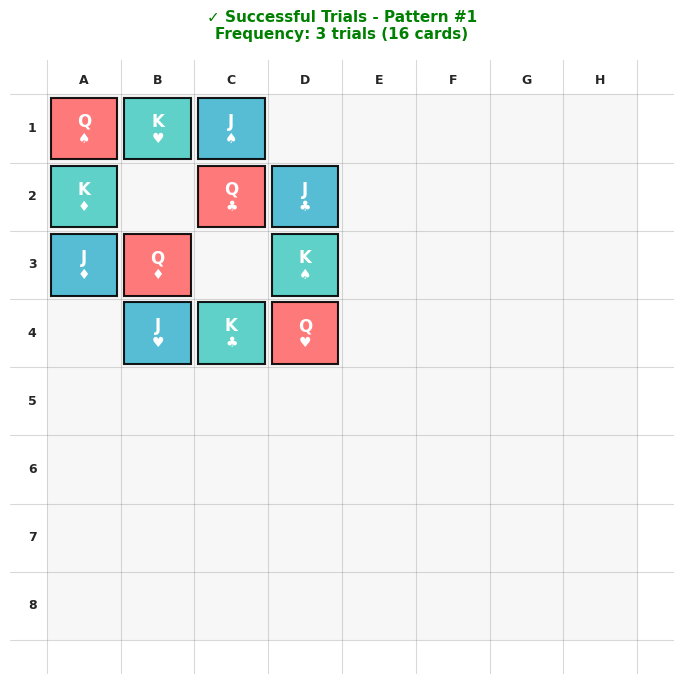


--- Pattern #2 ---
Frequency: 2 trials
Cards in pattern: 12


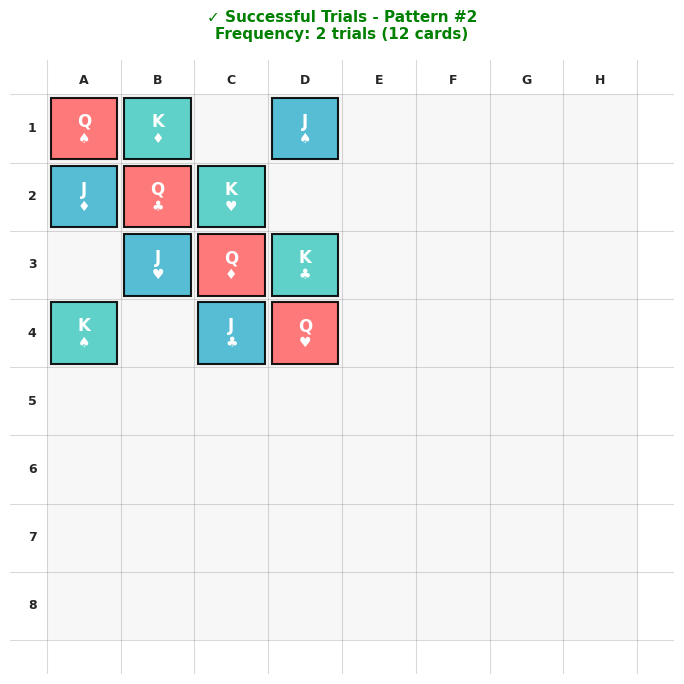


--- Pattern #3 ---
Frequency: 2 trials
Cards in pattern: 9


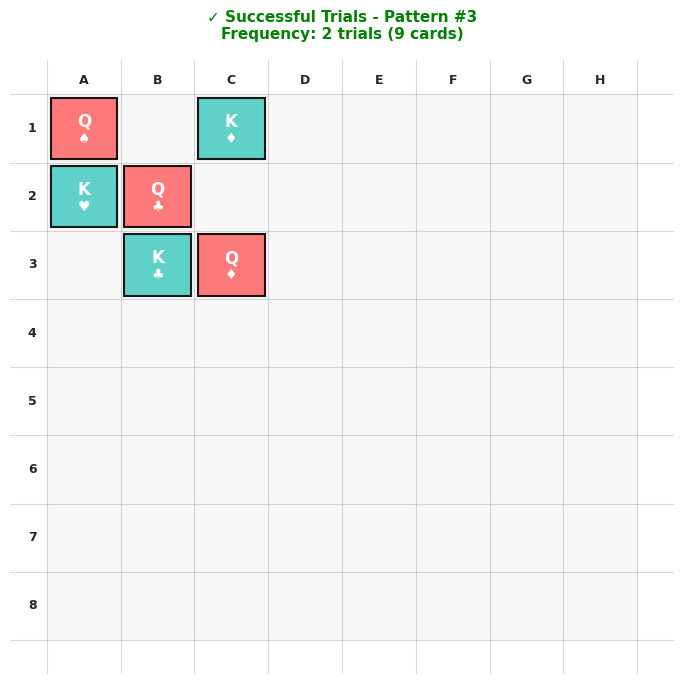


--- Pattern #4 ---
Frequency: 1 trials
Cards in pattern: 6


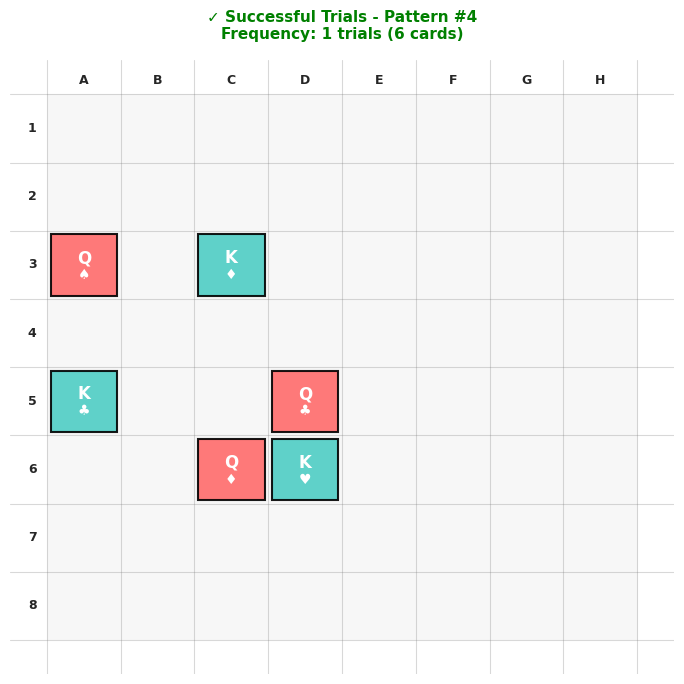


--- Pattern #5 ---
Frequency: 1 trials
Cards in pattern: 6


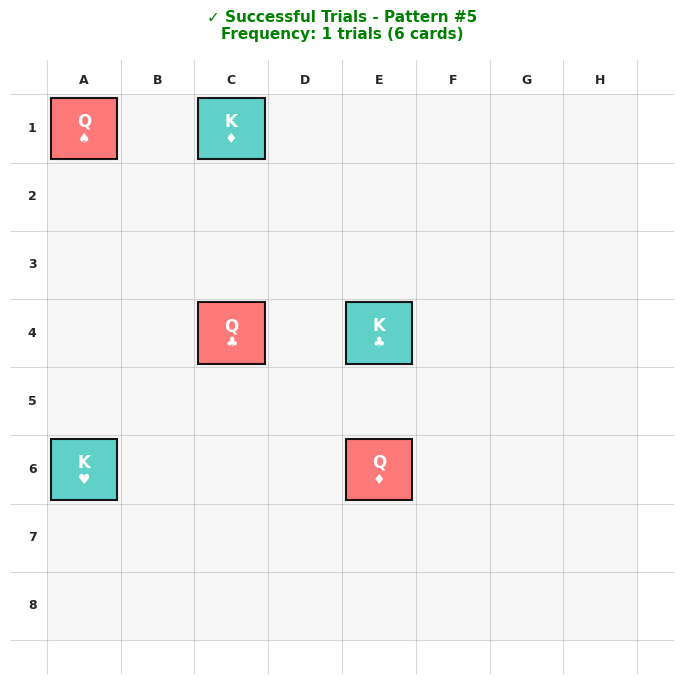

In [ ]:
# Visualize top patterns from successful trials
display_top_patterns(
    visualizer,
    success_final_positions,
    category_title="✓ Successful Trials",
    top_n=5
)


Top 5 Most Frequent Final Card Positions - ✗ Failed Trials


--- Pattern #1 ---
Frequency: 7 trials
Cards in pattern: 1


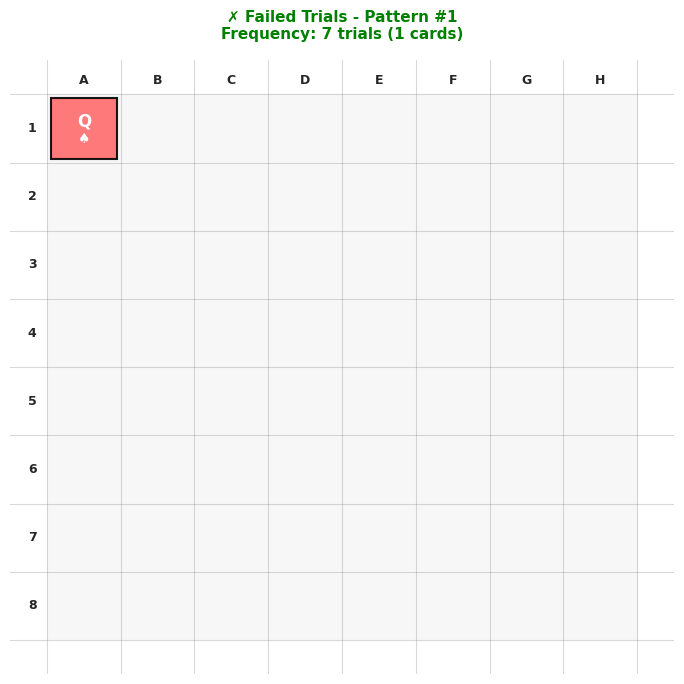


--- Pattern #2 ---
Frequency: 3 trials
Cards in pattern: 12


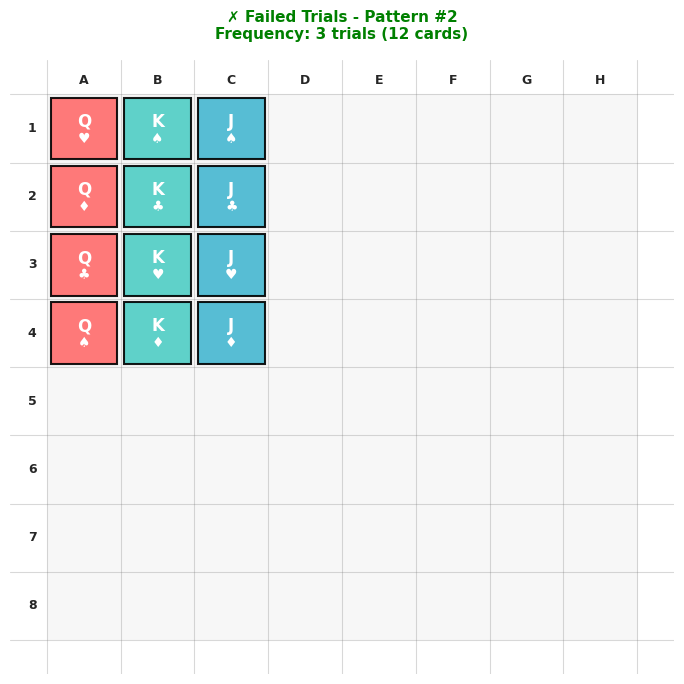


--- Pattern #3 ---
Frequency: 2 trials
Cards in pattern: 6


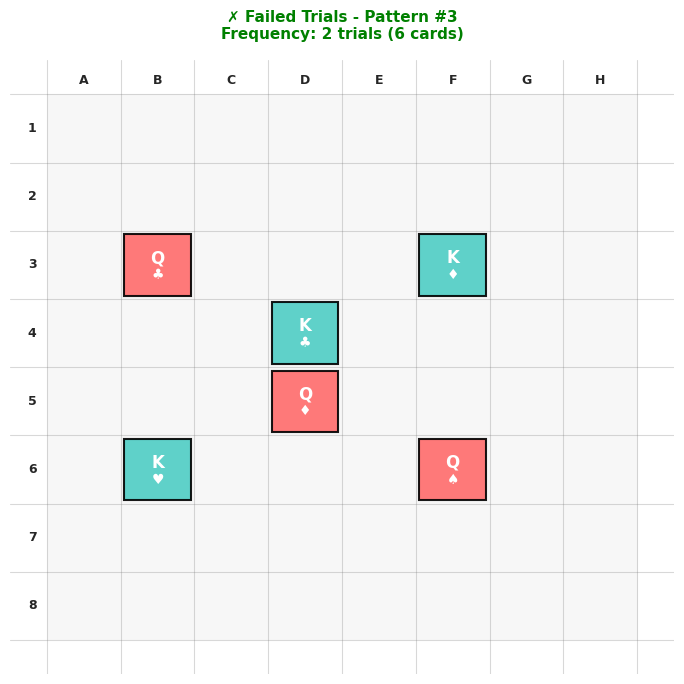


--- Pattern #4 ---
Frequency: 2 trials
Cards in pattern: 2


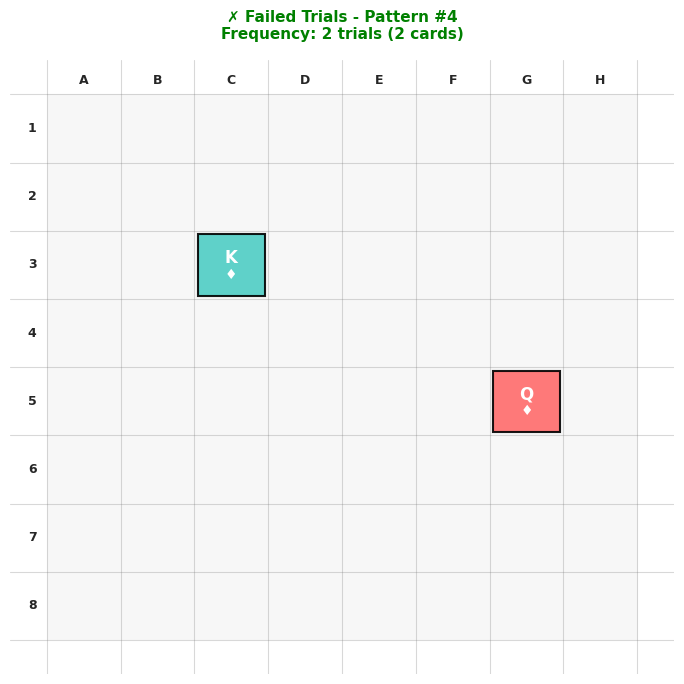


--- Pattern #5 ---
Frequency: 2 trials
Cards in pattern: 9


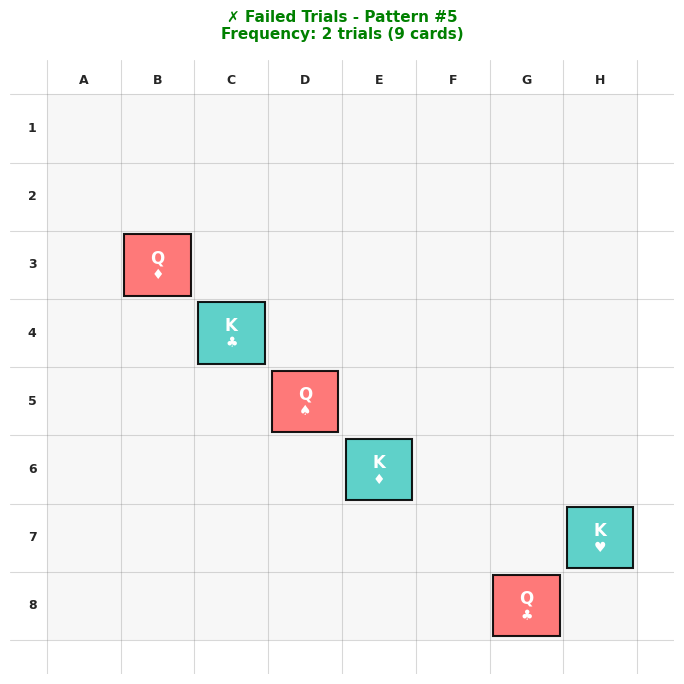

In [ ]:
# Visualize top patterns from failed trials
display_top_patterns(
    visualizer,
    failure_final_positions,
    category_title="✗ Failed Trials",
    top_n=5
)

In [ ]:
def find_all_trials_with_pattern(df_subset, target_pattern):
    """
    Find all trials that match the target final position pattern.

    Parameters:
    -----------
    df_subset : DataFrame
        Subset of trials to search
    target_pattern : tuple/list
        The target pattern to match

    Returns:
    --------
    list : List of trial information dictionaries
    """
    target_sorted = tuple(sorted(target_pattern))
    matching_trials = []

    for idx, row in df_subset.iterrows():
        final_positions = row['final_card_position_codes_1']
        if final_positions and len(final_positions) > 0:
            current_sorted = tuple(sorted(final_positions))
            if current_sorted == target_sorted:
                matching_trials.append({
                    'participant': row['participant'],
                    'trialN': row['trialN'],
                    'condition': row['condition'],
                    'overall_correct': row['overall_correct'],
                    'movements': row['movement_codes'],
                    'total_moves': len(row['movement_codes'])
                })

    return matching_trials

def create_interactive_pattern_explorer(visualizer, df_subset, category_title="Pattern Analysis", top_n=5):
    """
    Create an interactive explorer showing:
    - Left: Top N most frequent patterns with frequencies
    - Right: Interactive dropdown to select trial and view animation

    Parameters:
    -----------
    visualizer : CardPlacementVisualizer
        The visualizer instance
    df_subset : DataFrame
        Subset of trials (success_df or failure_df)
    category_title : str
        Title for the category
    top_n : int
        Number of top patterns to show
    """
    # Analyze patterns
    position_counter = Counter()
    for _, row in df_subset.iterrows():
        final_positions = row['final_card_position_codes_1']
        if final_positions and len(final_positions) > 0:
            position_tuple = tuple(sorted(final_positions))
            position_counter[position_tuple] += 1

    top_patterns = position_counter.most_common(top_n)

    if not top_patterns:
        print(f"No patterns found in {category_title}")
        return

    print(f"\n{'='*70}")
    print(f"{category_title} - Interactive Trial Selector")
    print(f"{'='*70}")
    print(f"Select a pattern from the top {top_n} to explore matching trials\n")

    # Create interactive widgets for right side
    # Pattern selector - create options as tuples (label, value)
    pattern_options = [(f"Pattern #{i+1} (Frequency: {count})", i)
                      for i, (pattern, count) in enumerate(top_patterns)]

    pattern_dropdown = Dropdown(
        options=pattern_options,
        value=0,
        description='Pattern:',
        style={'description_width': '100px'},
        layout=widgets.Layout(width='400px')
    )

    # Trial selector (will be populated based on pattern)
    trial_dropdown = Dropdown(
        options=[('Select a pattern first', None)],
        value=None,
        description='Trial:',
        style={'description_width': '100px'},
        layout=widgets.Layout(width='400px')
    )

    # Animate button
    animate_button = Button(
        description='🎬 Show Animation',
        button_style='success',
        layout=widgets.Layout(width='200px', height='40px')
    )

    # Show final state button
    final_button = Button(
        description='📊 Show Final State',
        button_style='info',
        layout=widgets.Layout(width='200px', height='40px')
    )

    # Output area
    output = widgets.Output()

    # Store current pattern data
    current_data = {'trials': [], 'pattern_idx': 0}

    def update_trials(*args):
        """Update trial dropdown when pattern changes."""
        pattern_idx = pattern_dropdown.value
        current_data['pattern_idx'] = pattern_idx

        pattern, count = top_patterns[pattern_idx]
        matching_trials = find_all_trials_with_pattern(df_subset, pattern)
        current_data['trials'] = matching_trials

        # Create options for trial dropdown
        trial_options = [
            (f"Participant {t['participant']}, Trial {t['trialN']} ({t['total_moves']} moves)", i)
            for i, t in enumerate(matching_trials)
        ]

        trial_dropdown.options = trial_options
        if trial_options:
            trial_dropdown.value = 0

        # Clear output
        output.clear_output()
        with output:
            print(f"Pattern #{pattern_idx + 1} selected")
            print(f"Found {len(matching_trials)} trials with this pattern")
            print(f"Select a trial and click 'Show Animation' or 'Show Final State'")

    def show_animation(b):
        """Show animation for selected trial."""
        if not current_data['trials'] or trial_dropdown.value is None:
            output.clear_output()
            with output:
                print("Please select a pattern and trial first")
            return

        trial_idx = trial_dropdown.value
        trial = current_data['trials'][trial_idx]

        output.clear_output(wait=True)
        with output:
            print(f"Generating animation for Pattern #{current_data['pattern_idx'] + 1}")
            print(f"Participant {trial['participant']}, Trial {trial['trialN']}")
            print(f"Condition: {trial['condition']}, Moves: {trial['total_moves']}\n")

            anim = visualizer.animate_trial(
                participant=trial['participant'],
                trial_n=trial['trialN']
            )

            if anim:
                display(HTML(anim.to_jshtml()))
                print("\n✓ Animation ready! Use controls to see step-by-step card placement.")

    def show_final(b):
        """Show final state for selected trial."""
        if not current_data['trials'] or trial_dropdown.value is None:
            output.clear_output()
            with output:
                print("Please select a pattern and trial first")
            return

        trial_idx = trial_dropdown.value
        trial = current_data['trials'][trial_idx]

        output.clear_output(wait=True)
        with output:
            print(f"Final State - Pattern #{current_data['pattern_idx'] + 1}")
            print(f"Participant {trial['participant']}, Trial {trial['trialN']}\n")

            fig, ax = plt.subplots(figsize=visualizer.figure_size)

            movements = trial['movements']
            grid = visualizer.create_grid_state(movements, len(movements))

            trial_info = {
                'participant': trial['participant'],
                'trialN': trial['trialN'],
                'condition': trial['condition'],
                'overall_correct': trial['overall_correct']
            }

            visualizer.plot_grid(grid, ax, len(movements), len(movements), trial_info)
            plt.tight_layout()
            plt.show()

            print(f"Total moves: {trial['total_moves']}")
            print(f"Result: {'✓ Success' if trial['overall_correct'] == 1 else '✗ Failed'}")

    # Set up event handlers
    pattern_dropdown.observe(update_trials, 'value')
    animate_button.on_click(show_animation)
    final_button.on_click(show_final)

    # Initialize
    update_trials()

    # Create layout
    controls = VBox([
        widgets.HTML("<h3>Select Pattern and Trial</h3>"),
        pattern_dropdown,
        trial_dropdown,
        widgets.HTML("<h3>Visualization Options</h3>"),
        HBox([animate_button, final_button]),
        widgets.HTML("<hr>")
    ])

    display(VBox([controls, output]))

print("✓ Interactive pattern explorer function loaded")

✓ Interactive pattern explorer function loaded


In [ ]:
# Interactive explorer for success patterns
create_interactive_pattern_explorer(
    visualizer=visualizer,
    df_subset=success_df,
    category_title="✓ Success Patterns",
    top_n=5
)


✓ Success Patterns - Interactive Trial Selector
Select a pattern from the top 5 to explore matching trials



In [ ]:
# Interactive explorer for failure patterns
create_interactive_pattern_explorer(
    visualizer=visualizer,
    df_subset=failure_df,
    category_title="✗ Failure Patterns",
    top_n=5
)


✗ Failure Patterns - Interactive Trial Selector
Select a pattern from the top 5 to explore matching trials

